In [6]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import pandas as pd

df = pd.read_excel("../dataset/CareerPilotAI_12000_RealWorld.xlsx")

print(df.head())

  Candidate_ID     Candidate_Name   Location     Education  \
0  CAND-100000     Charles Valdez     Remote           BCA   
1  CAND-100001  Charlene Saunders      Delhi           BCA   
2  CAND-100002    Paige Hernandez       Pune    B.Tech CSE   
3  CAND-100003      Samuel Hunter      Delhi  B.Tech AI&DS   
4  CAND-100004     Anthony Melton  Bangalore           BCA   

            Target_Role Experience_Level  Years_of_Experience  \
0     Android Developer         Advanced                  8.9   
1     Android Developer         Advanced                  9.3   
2  Full Stack Developer         Advanced                  8.6   
3          Data Analyst     Intermediate                  2.9   
4    Frontend Developer     Intermediate                  4.1   

                                              Skills   Primary_Tool  \
0       XML, CI/CD, Firebase, Kotlin, Android Studio         Gradle   
1  Kotlin, Android Studio, Kubernetes, Firebase, ...         SQLite   
2  Firebase, MongoDB, H

In [8]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(12000, 16)

Columns:
Index(['Candidate_ID', 'Candidate_Name', 'Location', 'Education',
       'Target_Role', 'Experience_Level', 'Years_of_Experience', 'Skills',
       'Primary_Tool', 'Projects_Completed', 'Certifications',
       'GitHub_Activity_Score', 'Expected_Salary_LPA', 'Preferred_Work_Mode',
       'Current_Company', 'Resume_Score'],
      dtype='str')

Missing Values:
Candidate_ID             0
Candidate_Name           0
Location                 0
Education                0
Target_Role              0
Experience_Level         0
Years_of_Experience      0
Skills                   0
Primary_Tool             0
Projects_Completed       0
Certifications           0
GitHub_Activity_Score    0
Expected_Salary_LPA      0
Preferred_Work_Mode      0
Current_Company          0
Resume_Score             0
dtype: int64


In [9]:
df['Target_Role'].value_counts()

Target_Role
Data Scientist            1060
Full Stack Developer      1042
Cloud Engineer            1036
Backend Developer         1026
Data Analyst              1022
AI Engineer                994
Software Engineer          988
Cyber Security Analyst     985
DevOps Engineer            980
Android Developer          974
Frontend Developer         957
ML Engineer                936
Name: count, dtype: int64

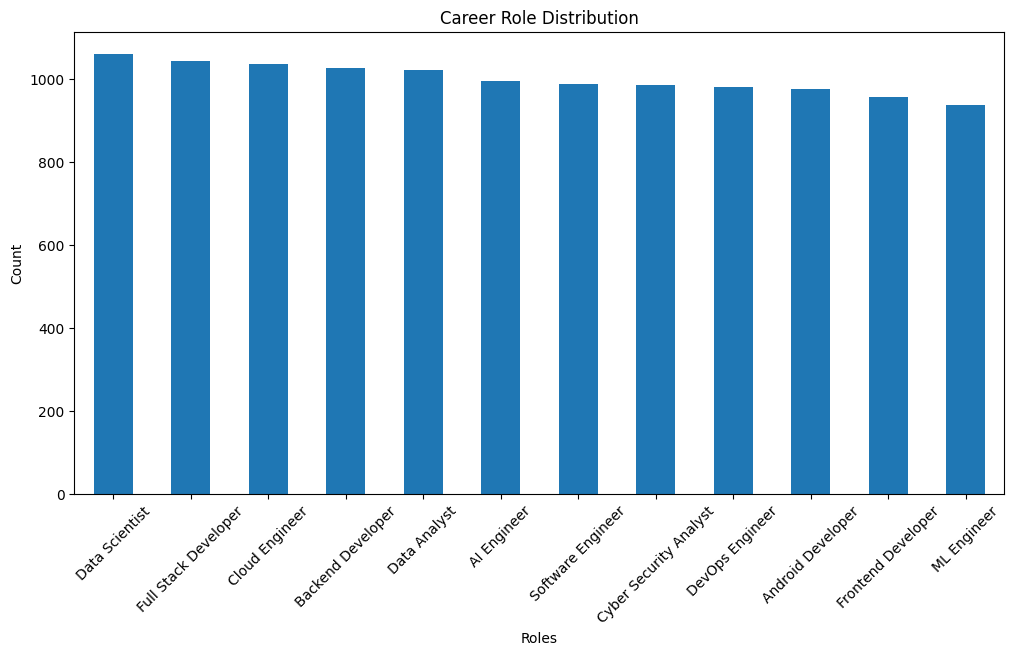

In [10]:
import matplotlib.pyplot as plt

df['Target_Role'].value_counts().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Career Role Distribution")

plt.xlabel("Roles")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [11]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required files
nltk.download('stopwords')
nltk.download('wordnet')

# Stopwords
stop_words = set(stopwords.words('english'))

# Lemmatizer
lemmatizer = WordNetLemmatizer()

print("NLP Libraries Ready")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vanga\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vanga\AppData\Roaming\nltk_data...


NLP Libraries Ready


In [12]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", " ", text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    # Join words
    return " ".join(words)

In [13]:
df['Cleaned_Skills'] = df['Skills'].apply(preprocess_text)

print(df[['Skills', 'Cleaned_Skills']].head())

                                              Skills  \
0       XML, CI/CD, Firebase, Kotlin, Android Studio   
1  Kotlin, Android Studio, Kubernetes, Firebase, ...   
2  Firebase, MongoDB, HTML, Express.js, React, Ja...   
3  Excel, MLOps, Deep Learning, Data Cleaning, Ta...   
4  TypeScript, CSS, HTML, Tailwind, Data Visualiz...   

                                      Cleaned_Skills  
0           xml ci cd firebase kotlin android studio  
1     kotlin android studio kubernetes firebase java  
2  firebase mongodb html express j react javascri...  
3  excel mlops deep learning data cleaning tablea...  
4  typescript cs html tailwind data visualization...  


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create vectorizer
vectorizer = TfidfVectorizer()

# Convert text into numerical vectors
X = vectorizer.fit_transform(
    df['Cleaned_Skills']
)

# Target column
y = df['Target_Role']

print("TF-IDF Transformation Complete")

print("\nFeature Matrix Shape:")
print(X.shape)

TF-IDF Transformation Complete

Feature Matrix Shape:
(12000, 63)


In [15]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Successful")

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

Train-Test Split Successful

Training Data Shape:
(9600, 63)

Testing Data Shape:
(2400, 63)


In [16]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [17]:
# Make predictions

y_pred = model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:")
print(accuracy)

Model Accuracy:
0.9783333333333334


In [19]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred
)

print(report)

                        precision    recall  f1-score   support

           AI Engineer       1.00      0.99      1.00       158
     Android Developer       1.00      1.00      1.00       191
     Backend Developer       1.00      1.00      1.00       201
        Cloud Engineer       0.90      0.91      0.91       220
Cyber Security Analyst       1.00      1.00      1.00       195
          Data Analyst       1.00      1.00      1.00       208
        Data Scientist       1.00      1.00      1.00       213
       DevOps Engineer       0.91      0.90      0.90       214
    Frontend Developer       0.97      0.98      0.98       196
  Full Stack Developer       0.98      0.97      0.98       193
           ML Engineer       0.99      1.00      1.00       196
     Software Engineer       1.00      1.00      1.00       215

              accuracy                           0.98      2400
             macro avg       0.98      0.98      0.98      2400
          weighted avg       0.98     

In [60]:
def predict_career(skills):

    # Clean text
    cleaned = preprocess_text(skills)

    # Convert into vector
    vector = vectorizer.transform([cleaned])

    # Predict role
    prediction = model.predict(vector)

    return prediction[0]

In [61]:
sample_skills = """
Python SQL Pandas Machine Learning
"""

result = predict_career(sample_skills)

print("Predicted Career Role:")
print(result)

Predicted Career Role:
Data Scientist


In [63]:
career_skills = {

    "Data Scientist": {

        "Core Skills": [
            "python",
            "machine learning",
            "statistics",
            "sql",
            "data analysis",
            "feature engineering",
            "deep learning",
            "nlp"
        ],

        "Libraries": [
            "pandas",
            "numpy",
            "scikit learn",
            "tensorflow",
            "pytorch"
        ],

        "Visualization Tools": [
            "power bi",
            "tableau",
            "matplotlib",
            "seaborn"
        ],

        "Cloud & Tools": [
            "aws",
            "docker",
            "git",
            "jupyter"
        ]
    },

    "AI Engineer": {

        "Core Skills": [
            "python",
            "deep learning",
            "nlp",
            "transformer",
            "llm"
        ],

        "Libraries": [
            "tensorflow",
            "pytorch",
            "hugging face",
            "langchain"
        ],

        "Tools": [
            "docker",
            "aws",
            "git",
            "linux"
        ]
    }
}

In [68]:
def advanced_skill_gap_analysis(
    user_skills,
    predicted_role
):

    # Clean user skills
    cleaned_skills = preprocess_text(
        user_skills
    )

    # Convert to list
    user_skill_list = cleaned_skills.split()

    # Get role data
    role_data = career_skills.get(
        predicted_role,
        {}
    )

    results = {}

    for category, skills in role_data.items():

        missing = []

        for skill in skills:

            # Preprocess required skill also
            processed_skill = preprocess_text(skill)

            skill_words = processed_skill.split()

            if not all(
                word in user_skill_list
                for word in skill_words
            ):

                missing.append(skill)

        results[category] = missing

    return results

In [69]:
def full_advanced_analysis(user_skills):

    # Predict role
    predicted_role = predict_career(
        user_skills
    )

    # Skill gap analysis
    gaps = advanced_skill_gap_analysis(
        user_skills,
        predicted_role
    )

    print("=" * 60)

    print("USER SKILLS:")
    print(user_skills)

    print("\nPREDICTED ROLE:")
    print(predicted_role)

    print("\nSKILL GAP ANALYSIS:\n")

    for category, missing in gaps.items():

        print(f"{category}:")

        if len(missing) == 0:

            print("  No Missing Skills 🎉")

        else:

            for skill in missing:

                print(f"  - {skill}")

        print()

    print("=" * 60)

In [70]:
sample = """
Python SQL Pandas Machine Learning
"""

full_advanced_analysis(sample)

USER SKILLS:

Python SQL Pandas Machine Learning


PREDICTED ROLE:
Data Scientist

SKILL GAP ANALYSIS:

Core Skills:
  - statistics
  - data analysis
  - feature engineering
  - deep learning
  - nlp

Libraries:
  - numpy
  - scikit learn
  - tensorflow
  - pytorch

Visualization Tools:
  - power bi
  - tableau
  - matplotlib
  - seaborn

Cloud & Tools:
  - aws
  - docker
  - git
  - jupyter



In [71]:
import pickle

pickle.dump(
    model,
    open("../models/career_model.pkl", "wb")
)

pickle.dump(
    vectorizer,
    open("../models/vectorizer.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [3]:
!pip install flask


Defaulting to user installation because normal site-packages is not writeable
